# <span style="color: yellow;"> Análisis de Absentismo Laboral - RRHH (13-JUL-2026)</span>

---

### Preguntas de negocio

> Cómo influyen  en los niveles de absentismo los factores de:
- el consumo social de alcohol
- el consumo social de tabaco 
- los antecedentes disciplinarios

 > Cómo podríamos diseñar acciones preventivas y culturales para promover un entorno laboral más saludable y minimizar el impacto del absentismo?
 ---

## Índice

1. Objetivo del análisis
2. Preparación del conjunto de datos
3. Categorización del absentismo
4. Regresión logística ordinal
5. Validación del modelo
   - 5.1 Multicolinealidad (VIF)
   - 5.2 Supuesto de proportional odds (Brant)
6. Interpretación de resultados
7. Conclusiones

---
### Metodología:

1. **Agregación por empleado.** Los registros del dataset son solicitudes de ausencia, no empleados individuales. Se agregan a nivel de persona para garantizar la independencia de las observaciones, un supuesto del modelo elegido.
2. **Creación de las categorías de absentismo.**
3. **Test Variance Inflation Factor (VIF)** o análisis de colinealidad para asegurar la no relación fuerte de información entre las variables independientes (predictoras).
3. **Realización del modelo**
4. Interpretación.


---
## 1. Objetivo del análisis

En un análisis anterior (regresión logística binaria) solo `Disciplinary_Failure` resultó significativa; el alcohol y el tabaco mostraron un efecto en la dirección esperada pero sin significación estadística:

| Variable | OR | p-valor |
|---|---|---|
| Consumo social de alcohol | 1,84 | 0,442 |
| Consumo social de tabaco | 1,94 | 0,328 |

Con solo dos grupos (alto/bajo absentismo) se pierde matiz, así que este sprint convierte el absentismo en **4 niveles ordinales** (Bajo, Medio, Alto, Severo) mediante bandas fijas de horas acumuladas, y ajusta un modelo de regresión logística ordinal para estimar el efecto de cada variable sobre esa escala.

> **¿Por qué una regresión ordinal?** La variable dependiente tiene un orden natural (Bajo < Medio < Alto < Severo) pero no es continua ni binaria. La regresión ordinal aprovecha ese orden para estimar un único efecto (Odds Ratio) por variable, válido para "subir un peldaño" en cualquier punto de la escala.

## 1.1 Imports

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from matplotlib.ticker import PercentFormatter, MaxNLocator
import scipy.stats as stats
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sqlalchemy.exc import SQLAlchemyError
from statsmodels.discrete.discrete_model import MNLogit
from statsmodels.miscmodels.ordinal_model import OrderedModel
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

---
## 2. Preparación del conjunto de datos

El dataset original tiene una fila por solicitud de ausencia, no por empleado. Antes de nada hay que agregarlo a nivel de persona: si se modelara a nivel de solicitud, un mismo empleado con muchas ausencias aparecería muchas veces, violando el supuesto de independencia de las observaciones que exige la regresión ordinal.

In [2]:
if input("¿Desea conectarse a la base de datos (sino cargará desde CSV)? (s/n): ").lower() == "s":

    load_dotenv(dotenv_path=".env")
    MYSQL_PASSWORD = os.getenv("MYSQL_PASSWORD")
    MYSQL_HOST = os.getenv("MYSQL_HOST")
    MYSQL_PORT = os.getenv("MYSQL_PORT")
    MYSQL_USER = os.getenv("MYSQL_USER")
    MYSQL_DATABASE = os.getenv("MYSQL_DATABASE")

    try:
        engine = create_engine(
            f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DATABASE}"
        )

        with engine.connect() :
            query = "SELECT * FROM RRHH_CLEAN_13072026;"
            df = pd.read_sql(query, engine)
        
        display("Datos de la base de datos cargados correctamente desde MySQL.")
        
    except SQLAlchemyError as error:
        display("No se pudo conectar o leer datos desde MySQL.")
        display(f"Detalle del error: {error}")
else:
    CSV_PATH = r'..\Data\DatasetClean_2026-07-13.csv'
    try:
        df = pd.read_csv(CSV_PATH)
        display("Datos cargados correctamente desde el archivo CSV.")

    except FileNotFoundError as error:
        raise FileNotFoundError(
            f"No se encontró el archivo CSV. Revisa la ruta: {CSV_PATH}"
    ) from error

'Datos cargados correctamente desde el archivo CSV.'

### Agregación por empleado

Se agrupa por `ID_Employee` sumando las horas de absentismo de cada persona; el resto de variables (consumo de alcohol/tabaco, falta disciplinaria) son constantes por empleado, así que basta con tomar el primer valor.

In [3]:
def prepare_dataset(df_raw):
    '''Agrega los registros de solicitudes de ausencia a nivel de empleado,
    garantizando la independencia de las observaciones.'''
    return (
        df_raw.groupby("ID_Employee", as_index=False)
        .agg(
            Total_Horas_Absentismo=("Absenteeism_Hours", "sum"),
            Social_Drinker=("Social_Drinker", "first"),
            Social_Smoker=("Social_Smoker", "first"),
            Disciplinary_Failure=("Disciplinary_Failure", "max"),
        )
    )


df_empleados = prepare_dataset(df)

print(f"Empleados únicos: {df_empleados.shape[0]}  |  Solicitudes originales: {df.shape[0]}")
df_empleados.head()

Empleados únicos: 386  |  Solicitudes originales: 1055


,ID_Employee,Total_Horas_Absentismo,Social_Drinker,Social_Smoker,Disciplinary_Failure
0,1,121,False,False,True
1,2,25,False,True,True
2,3,444,True,False,True
3,4,0,True,False,False
4,5,102,True,False,True


---
## 3. Categorización del absentismo

Las horas totales de absentismo se convierten en 4 niveles ordinales mediante bandas fijas, pensadas para reflejar el impacto operativo de la ausencia:

| Nivel | Horas acumuladas | Interpretación |
|---|---|---|
| Bajo | 0–8 h | Ausencias puntuales |
| Medio | 9–24 h | Requiere seguimiento |
| Alto | 25–80 h | Riesgo elevado |
| Severo | > 80 h | Intervención prioritaria |

*(1 turno laboral = 8 horas de ausencia)*

In [4]:
BANDAS_HORAS = [-np.inf, 8, 24, 80, np.inf]
ETIQUETAS_NIVEL = [0, 1, 2, 3]
categorias_ordenadas = ["Bajo", "Medio", "Alto", "Severo"]
mapa_categorias = {0: "Bajo", 1: "Medio", 2: "Alto", 3: "Severo"}

variables_modelo = ["Social_Drinker", "Social_Smoker", "Disciplinary_Failure"]

df_empleados["Nivel_Absentismo"] = pd.cut(
    df_empleados["Total_Horas_Absentismo"],
    bins=BANDAS_HORAS,
    labels=ETIQUETAS_NIVEL,
    right=True,
).astype(int)

df_empleados["Nivel_Absentismo_Desc"] = pd.Categorical(
    df_empleados["Nivel_Absentismo"].map(mapa_categorias),
    categories=categorias_ordenadas,
    ordered=True,
)

df_empleados.head()

,ID_Employee,Total_Horas_Absentismo,Social_Drinker,Social_Smoker,Disciplinary_Failure,Nivel_Absentismo,Nivel_Absentismo_Desc
0,1,121,False,False,True,3,Severo
1,2,25,False,True,True,2,Alto
2,3,444,True,False,True,3,Severo
3,4,0,True,False,False,0,Bajo
4,5,102,True,False,True,3,Severo


In [5]:
distribucion = df_empleados["Nivel_Absentismo_Desc"].value_counts().reindex(categorias_ordenadas)
distribucion

Nivel_Absentismo_Desc
Bajo      325
Medio      22
Alto       17
Severo     22
Name: count, dtype: int64

### Interpretación

Con bandas fijas, la mayoría de la plantilla se concentra en "Bajo" y las categorías superiores quedan con menos empleados — es el precio de usar cortes iguales para todos en lugar de percentiles de la propia muestra. Con una base de 386 empleados, conviene vigilar que "Medio" y "Alto" no queden demasiado pequeños, porque eso resta potencia estadística al modelo de la sección 4.

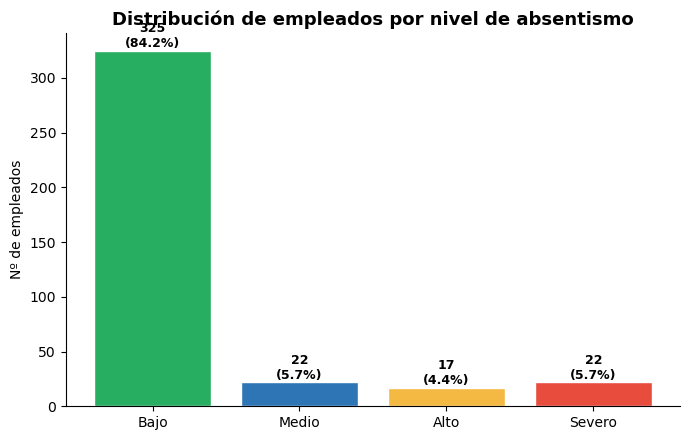

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
colores_niveles = ["#27AE60", "#2E75B6", "#F4B942", "#E74C3C"]
bars = ax.bar(distribucion.index, distribucion.values, color=colores_niveles, edgecolor="white")

for bar, val in zip(bars, distribucion.values):
    pct = val / distribucion.sum() * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3, f"{val}\n({pct:.1f}%)",
            ha="center", fontsize=9, fontweight="bold")

ax.set_title("Distribución de empleados por nivel de absentismo", fontsize=13, fontweight="bold")
ax.set_ylabel("Nº de empleados")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

### Jornadas de ausencia y distribución por perfil

Antes de pasar al modelo, conviene mirar los datos desde dos ángulos adicionales: cuántas jornadas de trabajo equivalen las horas acumuladas de cada nivel, y cómo se reparten los niveles de absentismo dentro de cada perfil (fumador/no fumador, bebedor/no bebedor, con/sin falta disciplinaria).

In [7]:
# 1. Convertir las horas acumuladas en dias equivalentes

horas_por_jornada = 8

df_empleados["Dias_Ausencia"] = (
    df_empleados["Total_Horas_Absentismo"] / horas_por_jornada
)


# 2. Preparar tabla para los graficos

resumen_niveles_grafico = (
    df_empleados
    .groupby(
        "Nivel_Absentismo_Desc",
        observed=False
    )
    .agg(
        Numero_Empleados=("ID_Employee", "count"),
        Total_Horas=("Total_Horas_Absentismo", "sum"),
        Dias_Ausencia=("Dias_Ausencia", "sum"),
        Media_Horas_Empleado=("Total_Horas_Absentismo", "mean"),
        Mediana_Horas_Empleado=("Total_Horas_Absentismo", "median")
    )
    .reindex(categorias_ordenadas)
    .reset_index()
)

resumen_niveles_grafico["Dias_Ausencia"] = (
    resumen_niveles_grafico["Dias_Ausencia"].round(1)
)

resumen_niveles_grafico["Media_Horas_Empleado"] = (
    resumen_niveles_grafico["Media_Horas_Empleado"].round(2)
)

resumen_niveles_grafico["Mediana_Horas_Empleado"] = (
    resumen_niveles_grafico["Mediana_Horas_Empleado"].round(2)
)

display(resumen_niveles_grafico)

,Nivel_Absentismo_Desc,Numero_Empleados,Total_Horas,Dias_Ausencia,Media_Horas_Empleado,Mediana_Horas_Empleado
0,Bajo,325,1299,162.4,4.00,3.0
1,Medio,22,437,54.6,19.86,18.5
2,Alto,17,724,90.5,42.59,34.0
3,Severo,22,5036,629.5,228.91,212.5


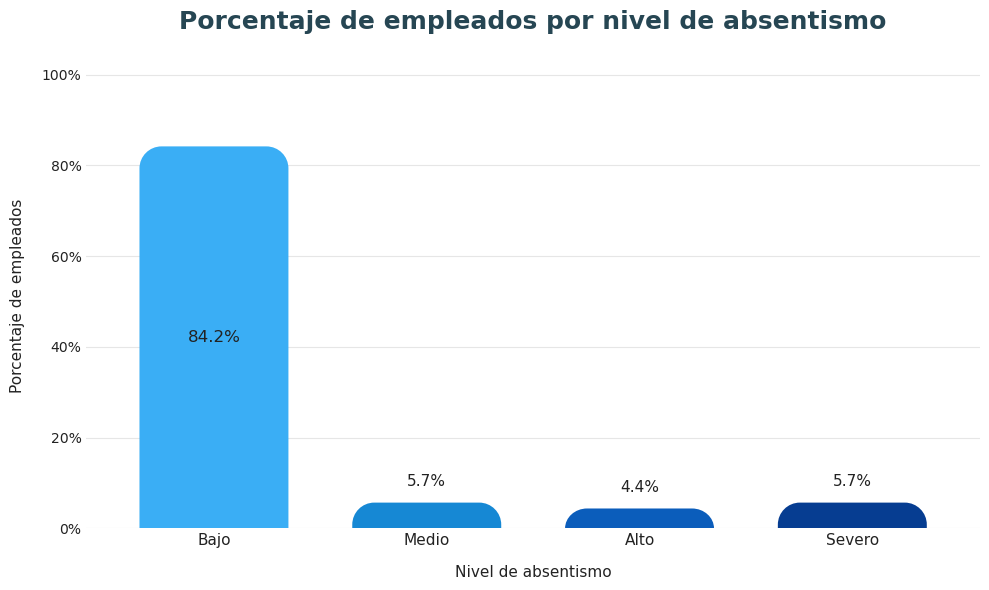

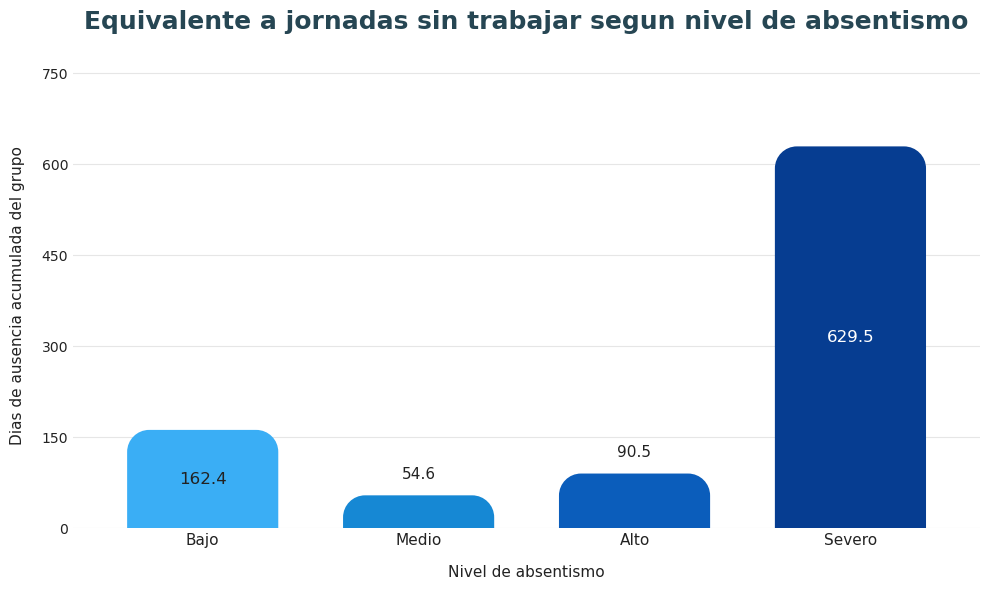

In [8]:
# 1. Preparar datos

niveles = (
    resumen_niveles_grafico["Nivel_Absentismo_Desc"]
    .astype(str)
    .tolist()
)

numero_empleados = (
    resumen_niveles_grafico["Numero_Empleados"]
    .astype(float)
    .to_numpy()
)

# Convertir numero de empleados en porcentaje
porcentaje_empleados = (
    numero_empleados / numero_empleados.sum() * 100
)

dias_ausencia = (
    resumen_niveles_grafico["Dias_Ausencia"]
    .astype(float)
    .to_numpy()
)


# 2. Estilo

colores = [
    "#3AAEF5",  # Bajo
    "#1688D4",  # Medio
    "#0B5DBB",  # Alto
    "#063D91"   # Severo
]

color_texto = "#222222"
color_titulo = "#264653"
color_grid = "#D9D9D9"
color_fondo = "#FFFFFF"


# 3. Funcion para dibujar barras redondeadas solo arriba

def crear_barra_superior_redondeada(
    ax,
    x_centro,
    altura,
    ancho,
    color,
    radio_pixeles=18
):
    """
    Crea una barra con:
    - esquinas inferiores cuadradas;
    - esquinas superiores redondeadas.
    """

    x0 = x_centro - ancho / 2
    x1 = x_centro + ancho / 2

    y0 = 0
    y1 = altura

    # Convertir el radio desde pixeles a unidades del grafico
    punto_origen_display = ax.transData.transform((0, 0))
    punto_origen_data = ax.transData.inverted().transform(
        punto_origen_display
    )

    punto_x_data = ax.transData.inverted().transform(
        punto_origen_display + np.array([radio_pixeles, 0])
    )

    punto_y_data = ax.transData.inverted().transform(
        punto_origen_display + np.array([0, radio_pixeles])
    )

    radio_x = abs(
        punto_x_data[0] - punto_origen_data[0]
    )

    radio_y = abs(
        punto_y_data[1] - punto_origen_data[1]
    )

    # Evitar que el redondeado sea mayor que la barra
    radio_x = min(radio_x, ancho / 2)
    radio_y = min(radio_y, altura)

    # Constante para aproximar un cuarto de circulo
    kappa = 0.5522847498

    vertices = [
        # Base inferior izquierda
        (x0, y0),

        # Base inferior derecha
        (x1, y0),

        # Lateral derecho hasta el inicio de la curva
        (x1, y1 - radio_y),

        # Curva superior derecha
        (
            x1,
            y1 - radio_y + kappa * radio_y
        ),
        (
            x1 - radio_x + kappa * radio_x,
            y1
        ),
        (
            x1 - radio_x,
            y1
        ),

        # Parte superior
        (
            x0 + radio_x,
            y1
        ),

        # Curva superior izquierda
        (
            x0 + radio_x - kappa * radio_x,
            y1
        ),
        (
            x0,
            y1 - radio_y + kappa * radio_y
        ),
        (
            x0,
            y1 - radio_y
        ),

        # Lateral izquierdo hasta la base
        (x0, y0),

        # Cerrar figura
        (x0, y0)
    ]

    codigos = [
        Path.MOVETO,
        Path.LINETO,
        Path.LINETO,

        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4,

        Path.LINETO,

        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4,

        Path.LINETO,
        Path.CLOSEPOLY
    ]

    barra = PathPatch(
        Path(vertices, codigos),
        facecolor=color,
        edgecolor="none",
        linewidth=0,
        zorder=3
    )

    ax.add_patch(barra)


# 4. Funcion general para crear cada grafico por separado

def crear_grafico_barras(
    categorias,
    valores,
    titulo,
    ylabel,
    colores,
    decimales=1,
    sufijo="",
    es_porcentaje=False,
    figsize=(10, 6),
    radio_pixeles=20
):
    valores = np.asarray(valores, dtype=float)

    fig, ax = plt.subplots(figsize=figsize)

    fig.patch.set_facecolor(color_fondo)
    ax.set_facecolor(color_fondo)

    x = np.arange(len(categorias))
    ancho = 0.70

    valor_maximo = (
        valores.max()
        if valores.max() > 0
        else 1
    )

    # Limites del grafico
    ax.set_xlim(
        -0.60,
        len(categorias) - 0.40
    )

    ax.set_ylim(
        0,
        valor_maximo * 1.22
    )

    # Eje X
    ax.set_xticks(x)

    ax.set_xticklabels(
        categorias,
        fontsize=11,
        color=color_texto
    )

    # Titulo
    ax.set_title(
        titulo,
        fontsize=18,
        fontweight="bold",
        color=color_titulo,
        pad=24
    )

    ax.set_xlabel(
        "Nivel de absentismo",
        fontsize=11,
        color=color_texto,
        labelpad=12
    )

    ax.set_ylabel(
        ylabel,
        fontsize=11,
        color=color_texto,
        labelpad=12
    )

    # Formato del eje Y
    if es_porcentaje:

        ax.yaxis.set_major_formatter(
            PercentFormatter(
                xmax=100,
                decimals=0
            )
        )

    else:

        ax.yaxis.set_major_locator(
            MaxNLocator(nbins=7)
        )

    # Cuadricula
    ax.grid(
        axis="y",
        linestyle="-",
        linewidth=0.8,
        alpha=0.65,
        color=color_grid,
        zorder=0
    )

    ax.set_axisbelow(True)

    # Quitar bordes
    for spine in [
        "top",
        "right",
        "left",
        "bottom"
    ]:
        ax.spines[spine].set_visible(False)

    ax.tick_params(
        axis="x",
        length=0,
        colors=color_texto
    )

    ax.tick_params(
        axis="y",
        length=0,
        colors=color_texto
    )

    # Ajustar primero el grafico para calcular correctamente
    # el radio visual de las esquinas
    plt.tight_layout()
    fig.canvas.draw()


    # Crear barras

    for posicion, valor, color in zip(
        x,
        valores,
        colores
    ):

        crear_barra_superior_redondeada(
            ax=ax,
            x_centro=posicion,
            altura=valor,
            ancho=ancho,
            color=color,
            radio_pixeles=radio_pixeles
        )

        etiqueta = (
            f"{valor:.{decimales}f}{sufijo}"
        )

        # Etiqueta dentro de barras suficientemente altas
        if valor >= valor_maximo * 0.18:

            color_etiqueta = (
                "white"
                if color in colores[2:]
                else color_texto
            )

            ax.text(
                posicion,
                valor / 2,
                etiqueta,
                ha="center",
                va="center",
                fontsize=12,
                fontweight="medium",
                color=color_etiqueta,
                zorder=4
            )

        # Etiqueta encima cuando la barra sea pequena
        else:

            ax.text(
                posicion,
                valor + valor_maximo * 0.035,
                etiqueta,
                ha="center",
                va="bottom",
                fontsize=11,
                fontweight="medium",
                color=color_texto,
                zorder=4
            )

    plt.show()


# 5. Grafico separado: porcentaje de empleados

crear_grafico_barras(
    categorias=niveles,
    valores=porcentaje_empleados,
    titulo="Porcentaje de empleados por nivel de absentismo",
    ylabel="Porcentaje de empleados",
    colores=colores,
    decimales=1,
    sufijo="%",
    es_porcentaje=True,
    figsize=(10, 6),
    radio_pixeles=22
)


# 6. Grafico separado: jornadas de ausencia

crear_grafico_barras(
    categorias=niveles,
    valores=dias_ausencia,
    titulo="Equivalente a jornadas sin trabajar segun nivel de absentismo",
    ylabel="Dias de ausencia acumulada del grupo",
    colores=colores,
    decimales=1,
    sufijo="",
    es_porcentaje=False,
    figsize=(10, 6),
    radio_pixeles=22
)

### Interpretación

El gráfico de jornadas revela una asimetría que el recuento de empleados por sí solo no muestra: aunque "Severo" tiene pocos empleados, concentra un número de jornadas perdidas desproporcionadamente alto frente a su tamaño — es el grupo que más pesa en términos de días de trabajo no cubiertos, no solo el más "grave" a nivel individual.

### Distribución de niveles por perfil de comportamiento

Antes de ajustar el modelo (sección 4), se puede ver de forma descriptiva cómo se reparte cada nivel de absentismo dentro de los dos grupos de cada variable (p. ej. fumadores vs. no fumadores).


Distribucion porcentual: Social_Smoker


Nivel_Absentismo_Desc,Bajo,Medio,Alto,Severo
Social_Smoker,,,,
0,85.03,5.65,3.67,5.65
1,75.00,6.25,12.50,6.25


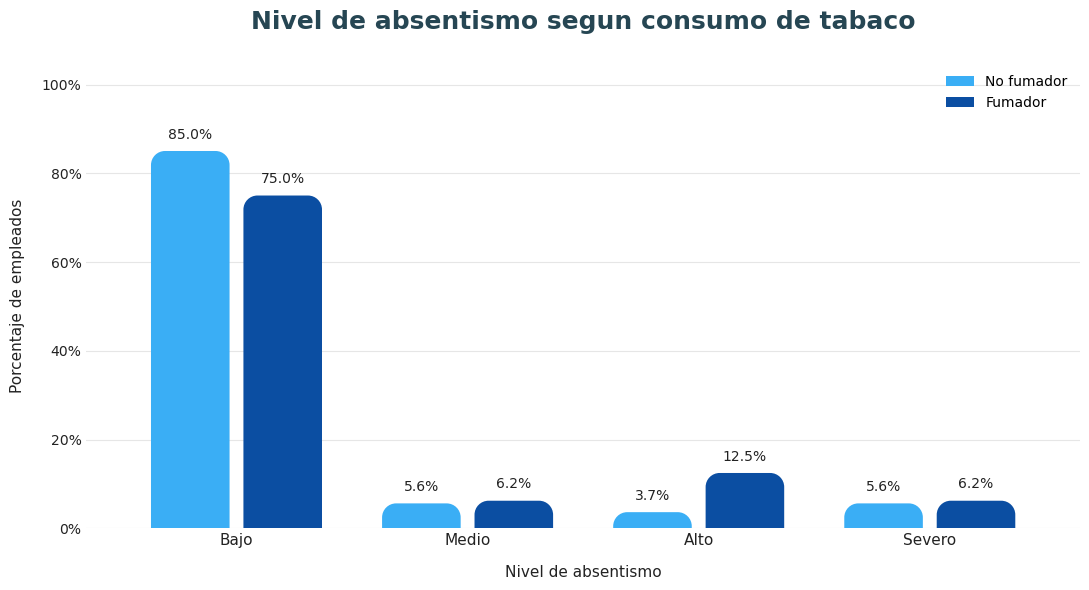


Distribucion porcentual: Social_Drinker


Nivel_Absentismo_Desc,Bajo,Medio,Alto,Severo
Social_Drinker,,,,
0,83.23,5.99,4.19,6.59
1,84.93,5.48,4.57,5.02


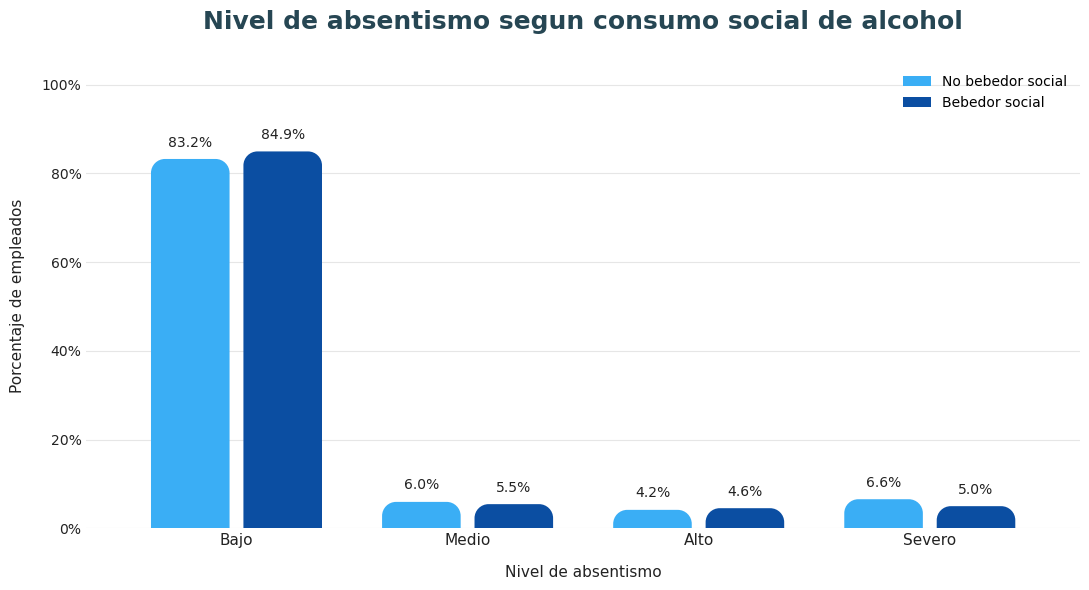


Distribucion porcentual: Disciplinary_Failure


Nivel_Absentismo_Desc,Bajo,Medio,Alto,Severo
Disciplinary_Failure,,,,
0,87.39,5.87,3.52,3.23
1,60.00,4.44,11.11,24.44


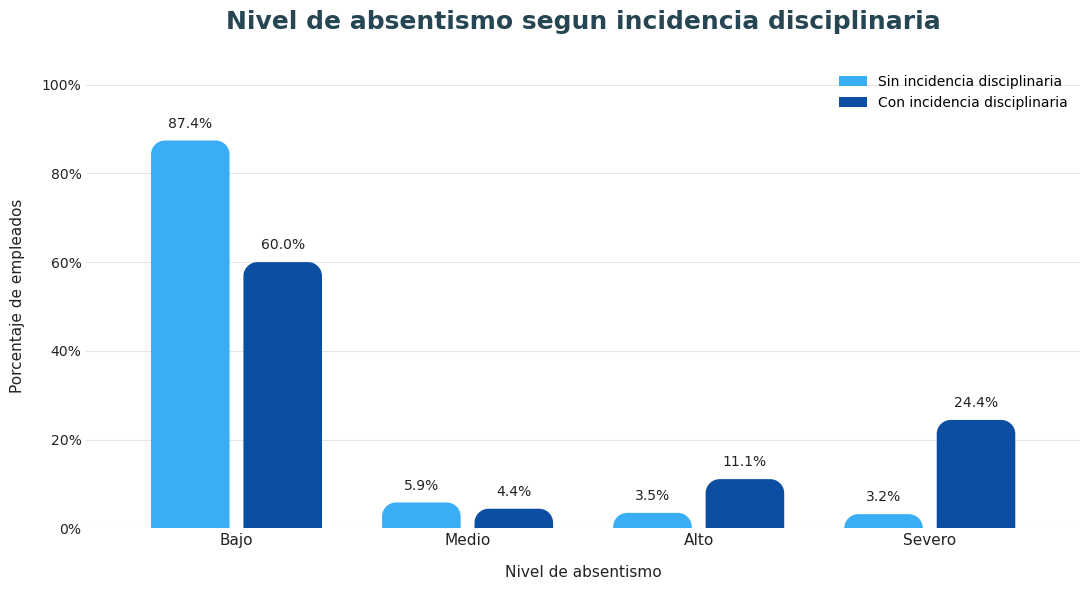

In [9]:
# 1. Configuracion

configuracion_variables = {
    "Social_Smoker": {
        "titulo": "Nivel de absentismo segun consumo de tabaco",
        "grupo_0": "No fumador",
        "grupo_1": "Fumador"
    },

    "Social_Drinker": {
        "titulo": "Nivel de absentismo segun consumo social de alcohol",
        "grupo_0": "No bebedor social",
        "grupo_1": "Bebedor social"
    },

    "Disciplinary_Failure": {
        "titulo": "Nivel de absentismo segun incidencia disciplinaria",
        "grupo_0": "Sin incidencia disciplinaria",
        "grupo_1": "Con incidencia disciplinaria"
    }
}

color_grupo_0 = "#3AAEF5"
color_grupo_1 = "#0B4EA2"

color_texto = "#222222"
color_titulo = "#264653"
color_grid = "#D9D9D9"
color_fondo = "#FFFFFF"


# 2. Barra con esquinas redondeadas solo arriba

def crear_barra_superior_redondeada_v2(
    ax,
    x_centro,
    altura,
    ancho,
    color,
    radio_pixeles=14
):
    x0 = x_centro - ancho / 2
    x1 = x_centro + ancho / 2

    y0 = 0
    y1 = altura

    origen_display = ax.transData.transform((0, 0))
    origen_data = ax.transData.inverted().transform(origen_display)

    punto_x = ax.transData.inverted().transform(
        origen_display + np.array([radio_pixeles, 0])
    )

    punto_y = ax.transData.inverted().transform(
        origen_display + np.array([0, radio_pixeles])
    )

    radio_x = abs(punto_x[0] - origen_data[0])
    radio_y = abs(punto_y[1] - origen_data[1])

    radio_x = min(radio_x, ancho / 2)
    radio_y = min(radio_y, altura)

    kappa = 0.5522847498

    vertices = [
        # Base inferior
        (x0, y0),
        (x1, y0),

        # Lateral derecho
        (x1, y1 - radio_y),

        # Esquina superior derecha
        (x1, y1 - radio_y + kappa * radio_y),
        (x1 - radio_x + kappa * radio_x, y1),
        (x1 - radio_x, y1),

        # Parte superior
        (x0 + radio_x, y1),

        # Esquina superior izquierda
        (x0 + radio_x - kappa * radio_x, y1),
        (x0, y1 - radio_y + kappa * radio_y),
        (x0, y1 - radio_y),

        # Lateral izquierdo
        (x0, y0),

        # Cerrar
        (x0, y0)
    ]

    codigos = [
        Path.MOVETO,
        Path.LINETO,
        Path.LINETO,

        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4,

        Path.LINETO,

        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4,

        Path.LINETO,
        Path.CLOSEPOLY
    ]

    barra = PathPatch(
        Path(vertices, codigos),
        facecolor=color,
        edgecolor="none",
        linewidth=0,
        zorder=3
    )

    ax.add_patch(barra)


# 3. Funcion para preparar los porcentajes

def calcular_porcentajes_por_perfil(df, variable):
    """
    Calcula la distribucion porcentual de los niveles de
    absentismo dentro de los grupos 0 y 1 de cada variable.
    """

    tabla = pd.crosstab(
        index=df[variable],
        columns=df["Nivel_Absentismo_Desc"],
        normalize="index"
    ) * 100

    tabla = tabla.reindex(
        index=[0, 1],
        columns=categorias_ordenadas,
        fill_value=0
    )

    return tabla


# 4. Funcion para crear cada grafico

def crear_grafico_comparativo(
    tabla,
    titulo,
    etiqueta_grupo_0,
    etiqueta_grupo_1,
    figsize=(11, 6)
):
    valores_grupo_0 = tabla.loc[0].to_numpy(dtype=float)
    valores_grupo_1 = tabla.loc[1].to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=figsize)

    fig.patch.set_facecolor(color_fondo)
    ax.set_facecolor(color_fondo)

    x = np.arange(len(categorias_ordenadas))

    ancho = 0.34
    separacion = 0.20

    posiciones_grupo_0 = x - separacion
    posiciones_grupo_1 = x + separacion

    valor_maximo = max(
        valores_grupo_0.max(),
        valores_grupo_1.max(),
        1
    )

    ax.set_xlim(-0.65, len(categorias_ordenadas) - 0.35)
    ax.set_ylim(0, min(105, valor_maximo * 1.25))

    ax.set_xticks(x)

    ax.set_xticklabels(
        categorias_ordenadas,
        fontsize=11,
        color=color_texto
    )

    ax.set_title(
        titulo,
        fontsize=18,
        fontweight="bold",
        color=color_titulo,
        pad=24
    )

    ax.set_xlabel(
        "Nivel de absentismo",
        fontsize=11,
        color=color_texto,
        labelpad=12
    )

    ax.set_ylabel(
        "Porcentaje de empleados",
        fontsize=11,
        color=color_texto,
        labelpad=12
    )

    ax.yaxis.set_major_formatter(
        PercentFormatter(xmax=100, decimals=0)
    )

    ax.grid(
        axis="y",
        linestyle="-",
        linewidth=0.8,
        alpha=0.65,
        color=color_grid,
        zorder=0
    )

    ax.set_axisbelow(True)

    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_visible(False)

    ax.tick_params(
        axis="x",
        length=0,
        colors=color_texto
    )

    ax.tick_params(
        axis="y",
        length=0,
        colors=color_texto
    )

    # Necesario para calcular bien el redondeado
    plt.tight_layout()
    fig.canvas.draw()


    # Barras del grupo 0

    for posicion, valor in zip(
        posiciones_grupo_0,
        valores_grupo_0
    ):
        crear_barra_superior_redondeada_v2(
            ax=ax,
            x_centro=posicion,
            altura=valor,
            ancho=ancho,
            color=color_grupo_0,
            radio_pixeles=14
        )

        ax.text(
            posicion,
            valor + valor_maximo * 0.025,
            f"{valor:.1f}%",
            ha="center",
            va="bottom",
            fontsize=10,
            color=color_texto,
            zorder=4
        )


    # Barras del grupo 1

    for posicion, valor in zip(
        posiciones_grupo_1,
        valores_grupo_1
    ):
        crear_barra_superior_redondeada_v2(
            ax=ax,
            x_centro=posicion,
            altura=valor,
            ancho=ancho,
            color=color_grupo_1,
            radio_pixeles=14
        )

        ax.text(
            posicion,
            valor + valor_maximo * 0.025,
            f"{valor:.1f}%",
            ha="center",
            va="bottom",
            fontsize=10,
            color=color_texto,
            zorder=4
        )

    # Leyenda manual
    leyenda_grupo_0 = PathPatch(
        Path.unit_rectangle(),
        facecolor=color_grupo_0,
        edgecolor="none",
        label=etiqueta_grupo_0
    )

    leyenda_grupo_1 = PathPatch(
        Path.unit_rectangle(),
        facecolor=color_grupo_1,
        edgecolor="none",
        label=etiqueta_grupo_1
    )

    ax.legend(
        handles=[leyenda_grupo_0, leyenda_grupo_1],
        frameon=False,
        loc="upper right",
        fontsize=10
    )

    plt.show()


# 5. Crear los tres graficos separados

for variable, configuracion in configuracion_variables.items():

    tabla_porcentajes = calcular_porcentajes_por_perfil(
        df=df_empleados,
        variable=variable
    )

    print(f"\nDistribucion porcentual: {variable}")
    display(tabla_porcentajes.round(2))

    crear_grafico_comparativo(
        tabla=tabla_porcentajes,
        titulo=configuracion["titulo"],
        etiqueta_grupo_0=configuracion["grupo_0"],
        etiqueta_grupo_1=configuracion["grupo_1"],
        figsize=(11, 6)
    )

### Interpretación

Estos tres gráficos son descriptivos (no controlan por las demás variables a la vez, a diferencia del modelo de la sección 4). Aun así, ya se intuye el patrón que confirmará el modelo: el grupo con incidencia disciplinaria muestra una proporción visiblemente mayor en los niveles "Alto" y "Severo" que el resto, mientras que las diferencias entre fumadores/no fumadores y bebedores/no bebedores son mucho más discretas.

---
## 4. Regresión logística ordinal

Se ajusta un modelo de regresión logística ordinal con `Social_Drinker`, `Social_Smoker` y `Disciplinary_Failure` como predictores de `Nivel_Absentismo`.

> ℹ️ **¿Qué es un Odds Ratio (OR)?** OR=1 → sin efecto. OR>1 → la variable aumenta la probabilidad de estar en un nivel más grave de absentismo. OR<1 → la reduce. El IC95% indica el rango plausible del efecto real; si incluye el 1, no se puede descartar que no haya efecto.

In [10]:
def fit_ordinal_model(df_emp, columna_nivel, variables):
    '''Ajusta un modelo de regresión logística ordinal (sin constante) y
    devuelve el resultado junto con los datos efectivamente utilizados.'''
    datos = df_emp[["ID_Employee", columna_nivel, *variables]].dropna().copy()
    datos[columna_nivel] = datos[columna_nivel].astype(int)
    datos[variables] = datos[variables].astype(int)

    X = datos[variables].astype(float)
    y = datos[columna_nivel]

    modelo = OrderedModel(endog=y, exog=X, distr="logit")
    resultado = modelo.fit(method="bfgs", maxiter=1000, disp=False)

    return resultado, X, y, datos


def extract_odds_ratios(resultado, variables):
    '''Tabla de coeficientes, odds ratios, IC95% y p-valores para las variables del modelo.'''
    coeficientes = resultado.params.loc[variables]
    p_values = resultado.pvalues.loc[variables]
    intervalos = resultado.conf_int().loc[variables]

    tabla = pd.DataFrame({
        "Variable": variables,
        "Coeficiente": coeficientes.values,
        "Odds_Ratio": np.exp(coeficientes.values),
        "IC_95_Inferior": np.exp(intervalos.iloc[:, 0].values),
        "IC_95_Superior": np.exp(intervalos.iloc[:, 1].values),
        "P_Value": p_values.values,
    })
    tabla["Significativa"] = np.where(tabla["P_Value"] < 0.05, "Sí", "No")
    tabla["Direccion"] = np.where(tabla["Odds_Ratio"] > 1, "Mayor probabilidad", "Menor probabilidad")

    return tabla.sort_values("P_Value").reset_index(drop=True)


def compute_pseudo_r2(resultado, y):
    '''Pseudo R² de McFadden, comparando la log-verosimilitud del modelo
    con la de un modelo nulo (solo distribución marginal de categorías).'''
    frecuencias = y.value_counts(normalize=True)
    llf_nulo = (y.value_counts() * np.log(frecuencias)).sum()
    return 1 - (resultado.llf / llf_nulo)


resultado, X, y, datos_modelo = fit_ordinal_model(df_empleados, "Nivel_Absentismo", variables_modelo)
pseudo_r2 = compute_pseudo_r2(resultado, y)
tabla_or = extract_odds_ratios(resultado, variables_modelo)

print(f"Convergencia: {resultado.mle_retvals.get('converged')}")
print(f"LogLik = {resultado.llf:.2f}  |  AIC = {resultado.aic:.2f}  |  Pseudo R² = {pseudo_r2:.4f}")
tabla_or.round(4)

Convergencia: True
LogLik = -223.68  |  AIC = 459.36  |  Pseudo R² = 0.0483


,Variable,Coeficiente,Odds_Ratio,IC_95_Inferior,IC_95_Superior,P_Value,Significativa,Direccion
0,Disciplinary_Failure,1.7108,5.5334,2.7386,11.1804,0.0000,Sí,Mayor probabilidad
1,Social_Drinker,-0.2284,0.7958,0.4514,1.4030,0.4297,No,Menor probabilidad
2,Social_Smoker,0.1059,1.1118,0.4460,2.7713,0.8202,No,Mayor probabilidad


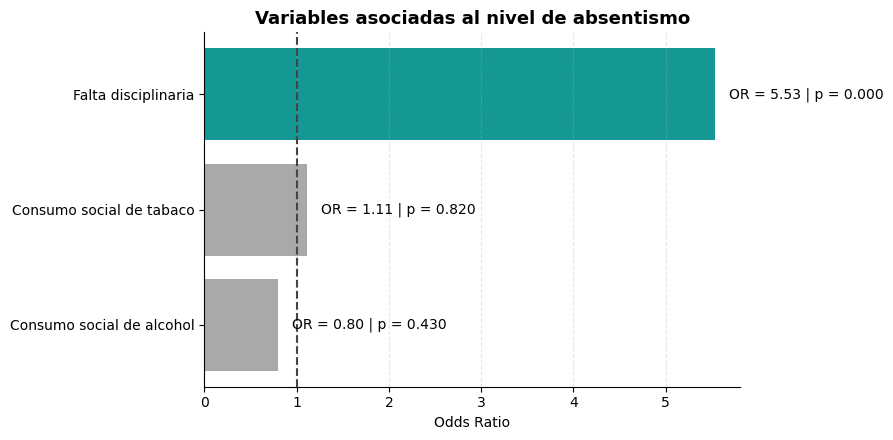

In [11]:
def plot_odds_ratios(tabla_or, titulo):
    '''Gráfico de barras horizontales de odds ratios, coloreado por significación.'''
    nombres_variables = {
        "Social_Drinker": "Consumo social de alcohol",
        "Social_Smoker": "Consumo social de tabaco",
        "Disciplinary_Failure": "Falta disciplinaria",
    }

    grafico = tabla_or.copy()
    grafico["Variable_Desc"] = grafico["Variable"].map(nombres_variables)
    grafico = grafico.sort_values("Odds_Ratio")

    colores = ["#159793" if p < 0.05 else "#A9A9A9" for p in grafico["P_Value"]]

    fig, ax = plt.subplots(figsize=(9, 4.5))
    bars = ax.barh(grafico["Variable_Desc"], grafico["Odds_Ratio"], color=colores)
    ax.axvline(1, color="#444444", linestyle="--", linewidth=1.5)

    for bar, or_value, p_value in zip(bars, grafico["Odds_Ratio"], grafico["P_Value"]):
        ax.text(
            bar.get_width() + 0.15,
            bar.get_y() + bar.get_height() / 2,
            f"OR = {or_value:.2f} | p = {p_value:.3f}",
            va="center",
            fontsize=10,
        )

    ax.set_title(titulo, fontsize=13, fontweight="bold")
    ax.set_xlabel("Odds Ratio")
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.show()


plot_odds_ratios(tabla_or, "Variables asociadas al nivel de absentismo")

### Interpretación

La barra que cruza la línea de OR=1 en color gris indica que no hay evidencia suficiente de efecto; las barras en color sí lo tienen. Es habitual que `Disciplinary_Failure` destaque claramente frente a las otras dos variables, tanto en magnitud del efecto como en significación.

In [12]:
df_empleados.describe()

,ID_Employee,Total_Horas_Absentismo,Nivel_Absentismo,Dias_Ausencia
count,386.000000,386.000000,386.000000,386.000000
mean,193.500000,19.419689,0.316062,2.427461
std,111.572846,59.963322,0.804921,7.495415
min,1.000000,0.000000,0.000000,0.000000
25%,97.250000,2.000000,0.000000,0.250000
50%,193.500000,4.000000,0.000000,0.500000
75%,289.750000,8.000000,0.000000,1.000000
max,386.000000,476.000000,3.000000,59.500000


---
## 5. Validación del modelo

Un modelo puede ajustarse sin errores técnicos y aun así violar sus propios supuestos — en ese caso, sus coeficientes no significan lo que aparentan. Se comprueban dos condiciones necesarias para que los odds ratios de la sección anterior sean interpretables: ausencia de multicolinealidad entre predictores y proporcionalidad de odds entre categorías.

### 5.1 Multicolinealidad (VIF)

> ℹ️ **¿Qué es el VIF?** Mide cuánto se infla el error de una variable por estar correlacionada con las demás — como comprobar cuántas variables son casi "clones" entre sí. VIF≈1: independencia total. VIF 1–5: aceptable. VIF>5: multicolinealidad preocupante.

In [13]:
def calculate_vif(datos, variables):
    '''VIF robusto: dropna + get_dummies + cast a int para evitar dtype object.'''
    df_filtrado = datos[variables].dropna()
    X_numerico = pd.get_dummies(df_filtrado, drop_first=True, dtype=int).astype(int)
    X_con_constante = add_constant(X_numerico)

    vif_df = pd.DataFrame()
    vif_df["Variable"] = X_con_constante.columns
    vif_df["VIF"] = [
        variance_inflation_factor(X_con_constante.values, i)
        for i in range(X_con_constante.shape[1])
    ]
    return vif_df[vif_df["Variable"] != "const"].reset_index(drop=True)


vif_df = calculate_vif(df_empleados, variables_modelo)
vif_df.round(4)

,Variable,VIF
0,Social_Drinker,1.0141
1,Social_Smoker,1.0412
2,Disciplinary_Failure,1.0457


**Conclusión**

Todos los factores presentan VIF cercanos a 1, muy por debajo de 5, por lo que no existe evidencia de multicolinealidad preocupante: los odds ratios de la sección 4 se pueden interpretar de forma independiente, sin que un predictor esté distorsionando el efecto estimado de otro.

### 5.2 Supuesto de proportional odds (Brant)

> ℹ️ **¿Qué verifica?** La regresión ordinal asume que el efecto de cada variable es el mismo en todos los "escalones" (Bajo→Medio, Medio→Alto, Alto→Severo) — el llamado supuesto de *proportional odds*. **¿Cómo se interpreta?** Aquí se aproxima comparando la log-verosimilitud del modelo ordinal con la de un modelo multinomial equivalente (que sí permite un efecto distinto por escalón); no es un Test de Brant formal, pero responde a la misma pregunta. **¿Qué implica para el modelo?** Si el supuesto se cumple (p>0.05), el modelo ordinal es válido y sus odds ratios únicos por variable son interpretables. Si no se cumple, el modelo fuerza una simplificación que no reflejan los datos, y sus coeficientes dejan de ser fiables.

In [14]:
def check_proportional_odds(datos, columna_nivel, variables):
    '''Comprobación del supuesto de proportional odds mediante un test de
    razón de verosimilitud entre el modelo ordinal y un modelo multinomial
    equivalente (aproximación; no es un Test de Brant formal).'''
    X = pd.get_dummies(datos[variables], drop_first=True, dtype=float)
    y_codes = datos[columna_nivel]

    modelo_ordinal = OrderedModel(y_codes, X, distr="logit").fit(method="bfgs", disp=False)
    X_con_constante = X.assign(const=1.0)
    modelo_multinomial = MNLogit(y_codes, X_con_constante).fit(disp=False)

    chi2_stat = 2 * (modelo_multinomial.llf - modelo_ordinal.llf)
    grados_libertad = modelo_multinomial.df_model - modelo_ordinal.df_model
    p_valor = 1 - stats.chi2.cdf(chi2_stat, grados_libertad)

    return {
        "chi2": chi2_stat,
        "df": grados_libertad,
        "p_value": p_valor,
        "cumple": p_valor > 0.05,
    }


prop_odds = check_proportional_odds(datos_modelo, "Nivel_Absentismo", variables_modelo)

print(f"chi2 = {prop_odds['chi2']:.4f}  |  df = {prop_odds['df']:.0f}  |  p-valor = {prop_odds['p_value']:.4f}")
if prop_odds["cumple"]:
    print("✅ El supuesto se CUMPLE. El modelo ordinal es estadísticamente válido.")
else:
    print("❌ El supuesto NO se cumple. Se debería considerar una regresión multinomial.")

chi2 = 9.6061  |  df = 6  |  p-valor = 0.1423
✅ El supuesto se CUMPLE. El modelo ordinal es estadísticamente válido.


**Conclusión**

Si el supuesto se cumple (p>0.05), el modelo ordinal es válido para su uso: los odds ratios estimados en la sección 4 reflejan un efecto constante y real a lo largo de toda la escala de absentismo. Si no se cumpliera, los resultados deberían tratarse como orientativos y contrastarse con un modelo multinomial.

---
## 6. Interpretación de resultados

Con la validación de la sección 5 confirmada, se puede leer el modelo con confianza.

### Variables significativas

✓ **`Disciplinary_Failure`** — significativa, con un odds ratio bien por encima de 1: tener una falta disciplinaria se asocia a mayor probabilidad de absentismo más severo.

• **`Social_Drinker`** — sin evidencia suficiente (el intervalo de confianza incluye el 1).

• **`Social_Smoker`** — sin evidencia suficiente (el intervalo de confianza incluye el 1).

---
## 7. Conclusiones
- Se categorizó el absentismo en 4 niveles mediante bandas fijas de horas y se ajustó un modelo de regresión logística ordinal.

- El modelo no mostró evidencia de multicolinealidad (VIF ≈ 1 en las tres variables).

- El supuesto de proportional odds se comprobó explícitamente (sección 5.2), en vez de asumirse sin más.

**Principales hallazgos**

- `Disciplinary_Failure` es el principal predictor del absentismo.

- No se encontró evidencia suficiente de el consumo social de alcohol ni de tabaco como buenos predictores para el nivel de absentismo alto..

**Limitaciones**

- La definición de los niveles mediante bandas fijas es una convención, no un estándar universal: en la literatura no hay un único criterio para todas las empresas. Guardamos para el futuro la opción alternativa de crear los 4 niveles de absentismo de la empresa mediante una matriz que combine pocas/muchas solicitudes y pocas/muchas horas de ausencia (validada pero requiere más registros en cada categoría y el modelo sería multinomial).
- Muestra reducida a nivel de empleado: las categorías menos pobladas generan estimaciones menos precisas.
- Los resultados no son causales: son punto de partida para hipótesis de intervención, no una prueba de causa-efecto.

**Próximos pasos sugeridos:** contrastar el hallazgo de `Disciplinary_Failure` con RRHH para entender el mecanismo (¿la falta disciplinaria precede o sigue al absentismo?), y explorar una muestra ampliada o variables de control adicionales (antigüedad, carga de trabajo,etc.) para dar más potencia a alcohol y tabaco.

---
## Anexo — Justificación estadística del modelo

1) **¿Por qué esta técnica de análisis?** La variable dependiente tiene 4 niveles con orden natural (bajo, medio, alto, severo), por lo que la regresión logística ordinal es más adecuada que una regresión lineal (que trabajaría con horas exactas, no con niveles de gravedad) o que tratar la variable como puramente categórica sin orden.

2) **¿Qué supuestos tiene y cómo se comprobaron?**
   - Variable dependiente ordinal — por construcción (sección 3).
   - Independencia de observaciones — agregación por empleado (sección 2).
   - Ausencia de multicolinealidad — VIF (sección 5.1).
   - Proporcionalidad de odds — comprobación tipo Brant (sección 5.2).

3) **Limitaciones:** muestra limitada de empleados; no existe un estándar único de categorización del absentismo en la literatura; el modelo detecta asociaciones, no relaciones de causa, de cara a diseñar medidas internas.